In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
import itertools

#Creación

In [2]:
np.random.seed(42)

# Cantidad de muestras
n_samples = 500

# Parámetros usados al generar los datos
loc = 50
scale = 10

# Generamos datos normales
data = np.random.normal(loc=loc, scale=scale, size=(n_samples, 5))

# Insertamos outliers en algunas filas (por ejemplo, en el 10%)
n_outliers = int(0.2 * n_samples)
outlier_indices = np.random.choice(n_samples, n_outliers, replace=False)

# Añadimos outliers proporcionales al loc y scale
for idx in outlier_indices:
    col = np.random.randint(0, 5)
    data[idx, col] = np.random.choice([
        np.random.uniform(loc + 4 * scale, loc + 6 * scale),  # outlier alto
        np.random.uniform(loc - 6 * scale, loc - 4 * scale)   # outlier bajo
    ])

# Creamos el DataFrame
columns = [f'feature_{i+1}' for i in range(5)]
df = pd.DataFrame(data, columns=columns)

# Añadimos la columna 'is_outlier'
df['is_outlier'] = 0
df.loc[outlier_indices, 'is_outlier'] = 1

df = df.drop_duplicates()

# Mostramos algunas filas
print(df.head(10))


   feature_1  feature_2  feature_3  feature_4  feature_5  is_outlier
0  54.967142  48.617357  56.476885  65.230299  47.658466           0
1  47.658630  65.792128  57.674347  45.305256  55.425600           0
2  45.365823  45.342702  52.419623  30.867198  32.750822           0
3  44.377125  39.871689  53.142473  40.919759  35.876963           0
4  64.656488  47.742237  50.675282  35.752518  44.556173           0
5  51.109226  38.490064  53.756980  43.993613  47.083063           0
6  43.982934  68.522782  49.865028  39.422891  58.225449           0
7  37.791564  52.088636  30.403299  36.718140  51.968612           0
8  96.720141  51.713683  48.843517  46.988963  35.214780           1
9  42.801558  45.393612   1.417548  53.436183  32.369598           1


In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_and_plot(X, y, n_components=2, figura_x=8, figura_y=6):
    """
    Función para aplicar PCA, reducir la dimensionalidad y graficar los resultados.

    Parameters:
    df (pd.DataFrame): El DataFrame con los datos.
    target_column (str): Nombre de la columna objetivo (por defecto 'is_outlier').
    n_components (int): Número de componentes principales para PCA (por defecto 2).
    figura_x (int): Ancho de la figura del gráfico.
    figura_y (int): Alto de la figura del gráfico.

    Returns:
    fig: Figura generada con el gráfico.
    pca_df: DataFrame con las dos componentes principales.
    """

    # Normalizar los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Aplicar PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(X_scaled)

    # Crear un DataFrame con las componentes principales, y usar el índice de X
    pca_df = pd.DataFrame(data=pca_result, columns=[f'PCA {i+1}' for i in range(n_components)], index=X.index)

    # Graficar los resultados
    fig, ax = plt.subplots(figsize=(figura_x, figura_y))

    y = y.loc[pca_df.index]  # Asegura que y tenga el mismo índice que pca_df

    # Filtrar los datos para los dos grupos
    normal_data = pca_df[y == 0]  # Datos normales
    outlier_data = pca_df[y == 1]  # Outliers

    # Graficar los dos grupos con colores diferentes
    ax.scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
    ax.scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='Outliers', alpha=0.8)

    # Títulos y etiquetas
    ax.set_title('PCA - Reducción de Dimensionalidad')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.legend()

    plt.grid(True)

    return fig, pca_df

In [4]:
def graficos(nombre, pca_df, y, outliers_results):
# Filtrar los datos para los dos grupos

    # Reset index before accessing by index
  pca_df = pca_df.reset_index(drop=True)
  outliers_results = outliers_results.reset_index(drop=True)
  y = y.reset_index(drop=True) # Reset index of y as well

  normal_data = pca_df[y == 0]  # Asumiendo que los datos normales son 0 en 'y'
  outlier_data = pca_df[y == 1]  # Asumiendo que los outliers son 1 en 'y'

  # Crear una figura con 4 subplots (2 filas x 2 columnas)
  fig, axes = plt.subplots(2, 2, figsize=(12, 10))
  fig.suptitle(f'Comparación de base vs métricas de {nombre}')

  # Scatter plot 1: base vs accuracy
  axes[0, 0].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[0, 0].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_accuracy"] == True].index
  axes[0, 0].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], c='#ff7f0e', label='Outliers', marker='x')
  axes[0, 0].set_title('Base vs Accuracy')

  # Scatter plot 2: base vs recall
  axes[0, 1].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[0, 1].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_recall"] == True].index
  axes[0, 1].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], color='#ff7f0e', label='Outliers', marker='x')
  axes[0, 1].set_title('Base vs Recall')

  # Scatter plot 3: base vs precision
  axes[1, 0].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[1, 0].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_precision"] == True].index
  axes[1, 0].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], color='#ff7f0e', label='Outliers', marker='x')
  axes[1, 0].set_title('Base vs Precision')

  # Scatter plot 4: base vs f1
  axes[1, 1].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[1, 1].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_f1"] == True].index
  axes[1, 1].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], color='#ff7f0e', label='Outliers', marker='x')
  axes[1, 1].set_title('Base vs F1 Score')

  # Ajustar el espacio entre subplots
  plt.tight_layout()
  plt.show()

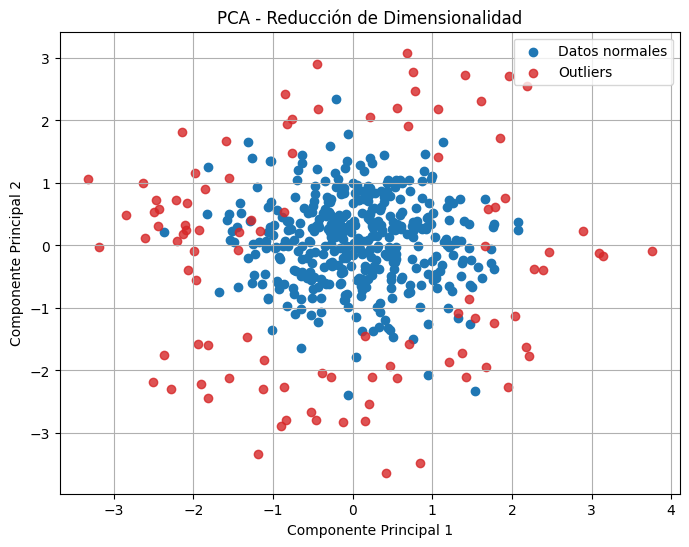

In [5]:
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df.drop(columns=['is_outlier']), df['is_outlier'])

# Mostrar la figura
plt.show()

#Detección

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_multiple_confusion_matrices(y_trues_preds, titles, class_names=['Falso', 'Verdadero']):
    """
    y_trues_preds: lista de tuplas (y_true, y_pred)
    titles: lista de títulos para cada matriz
    class_names: etiquetas de las clases
    """

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Múltiples Matrices de Confusión')

    for idx, ((y_true, y_pred), title) in enumerate(zip(y_trues_preds, titles)):

        # Imprimir el classification_report (opcional)
        print(f"--- {title} ---")
        print(classification_report(y_true, y_pred, target_names=class_names))

        cm = confusion_matrix(y_true, y_pred)
        row, col = divmod(idx, 2)
        ax = axes[row, col]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [7]:
def detectar_anomalias_iqr(df, umbral=0.01):
    aux = pd.DataFrame()
    aux['anomalo'] = False
    anomales = None
    for columna in df:
        Q1 = df[columna].quantile(0.25)
        Q3 = df[columna].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - umbral * IQR
        limite_superior = Q3 + umbral * IQR

        anomalos = (df[columna] < limite_inferior) | (df[columna] > limite_superior)

    return anomalos

In [8]:
  # Función para actualizar los mejores resultados
def update_best_scores(best, best_umbral, n_outliers, model, metric ,score, umbral, outliers, outliers_results):
    if score > best[metric]:
      best[metric] = score
      best_umbral[metric] = umbral
      outliers_results[f'{model}_{metric}'] = outliers
      n_outliers[metric] = outliers.sum()

def algoritmo(df):
    X = df.drop(columns=['is_outlier'])
    y = df['is_outlier']
    outliers_results = pd.DataFrame()
    outliers_results['base'] = df['is_outlier']

    umbral_values = np.linspace(0.5, 3.5, 100)



    # Diccionarios para almacenar los mejores resultados
    best = {'accuracy': -float('inf'), 'recall': -float('inf'),
                'precision': -float('inf'), 'f1': -float('inf')}
    best_umbral = {'accuracy': 0, 'recall': 0, 'precision': 0, 'f1': 0}
    n_outliers = {'accuracy': 0, 'recall': 0, 'precision': 0, 'f1': 0}
    # Realizar el grid search
    for umbral in umbral_values:
        # Aplicar K-Means
        # Aplicar Isolation Forest
        outliers = detectar_anomalias_iqr(X, umbral=umbral)


        # Calcular las métricas
        current_accuracy = accuracy_score(y_true=y, y_pred=outliers)
        current_recall = recall_score(y_true=y, y_pred=outliers, zero_division=0)
        current_precision = precision_score(y_true=y, y_pred=outliers, zero_division=0)
        current_f1 = f1_score(y_true=y, y_pred=outliers, zero_division=0)

        # Actualizar los mejores resultados
        update_best_scores(best, best_umbral, n_outliers, 'Rango Intercuartílico', 'accuracy', current_accuracy, umbral, outliers, outliers_results)
        update_best_scores(best, best_umbral, n_outliers, 'Rango Intercuartílico', 'recall', current_recall, umbral, outliers, outliers_results)
        update_best_scores(best, best_umbral, n_outliers, 'Rango Intercuartílico', 'precision', current_precision, umbral, outliers, outliers_results)
        update_best_scores(best, best_umbral, n_outliers, 'Rango Intercuartílico', 'f1', current_f1, umbral, outliers, outliers_results)

    # Crear DataFrame a partir de los diccionarios
    df_lof = pd.DataFrame({
        'Metric': best.keys(),
        'Best Score': best.values(),
        'Best umbral': best_umbral.values(),
        'Number of Outliers': n_outliers.values()
    })

    return df_lof, y, outliers_results


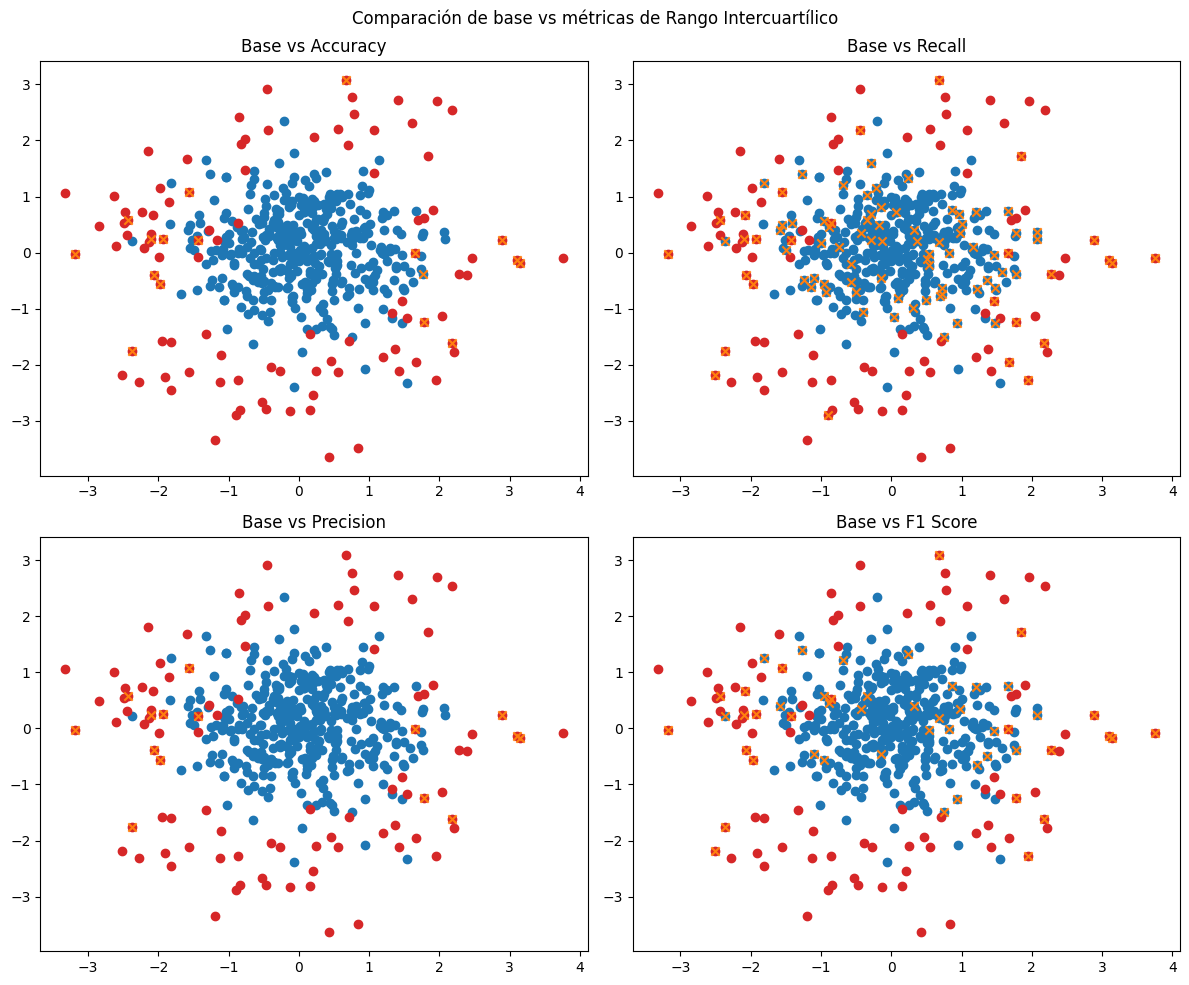

In [9]:
import matplotlib.pyplot as plt

model = 'Rango Intercuartílico'
df_iqr, y, outliers_results = algoritmo(df)
graficos(model, pca, y, outliers_results)


In [10]:
df_iqr

,Metric,Best Score,Best umbral,Number of Outliers
0,accuracy,0.830000,1.439394,17
1,recall,0.270000,0.500000,94
2,precision,1.000000,2.257576,15
3,f1,0.304636,0.772727,51


--- Rango Intercuartílico_accuracy ---
              precision    recall  f1-score   support

       Falso       0.83      1.00      0.90       400
   Verdadero       0.94      0.16      0.27       100

    accuracy                           0.83       500
   macro avg       0.88      0.58      0.59       500
weighted avg       0.85      0.83      0.78       500

--- Rango Intercuartílico_recall ---
              precision    recall  f1-score   support

       Falso       0.82      0.83      0.83       400
   Verdadero       0.29      0.27      0.28       100

    accuracy                           0.72       500
   macro avg       0.55      0.55      0.55       500
weighted avg       0.71      0.72      0.72       500

--- Rango Intercuartílico_precision ---
              precision    recall  f1-score   support

       Falso       0.82      1.00      0.90       400
   Verdadero       1.00      0.15      0.26       100

    accuracy                           0.83       500
   macro avg

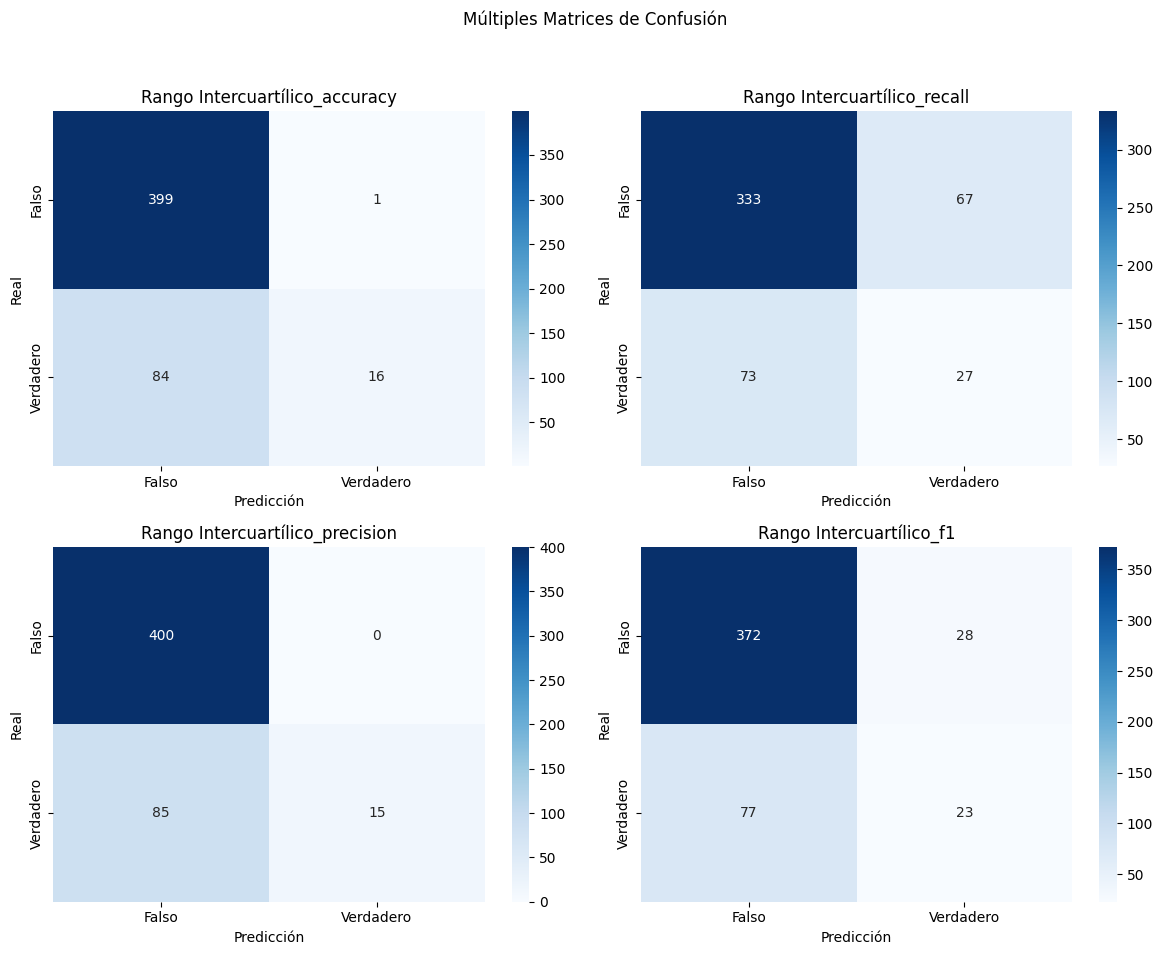

In [11]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)

#Tratamiento

In [12]:
result = outliers_results[f"{model}_f1"]

##Dejar los outliers

In [13]:
df_completo = df.copy()
df_completo = df_completo.drop_duplicates()

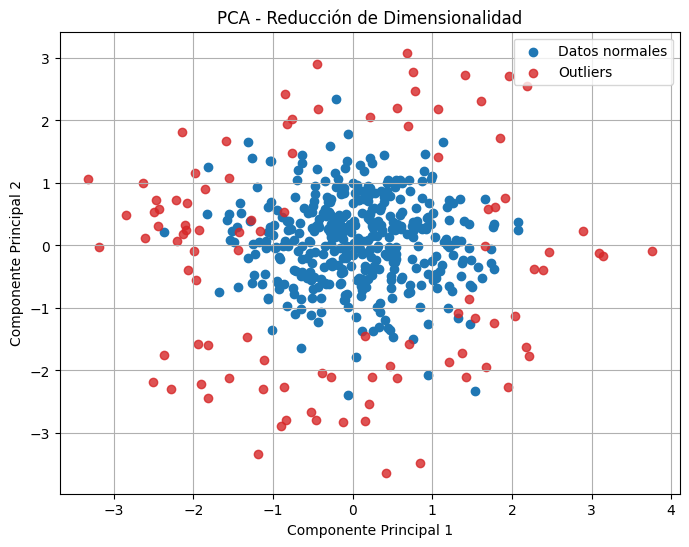

In [14]:
df_iso_completo, y, outliers_results = algoritmo(df_completo)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_completo.drop(columns=['is_outlier']), df_completo['is_outlier'])

plt.show()

In [15]:
df_iso_completo

,Metric,Best Score,Best umbral,Number of Outliers
0,accuracy,0.830000,1.439394,17
1,recall,0.270000,0.500000,94
2,precision,1.000000,2.257576,15
3,f1,0.304636,0.772727,51


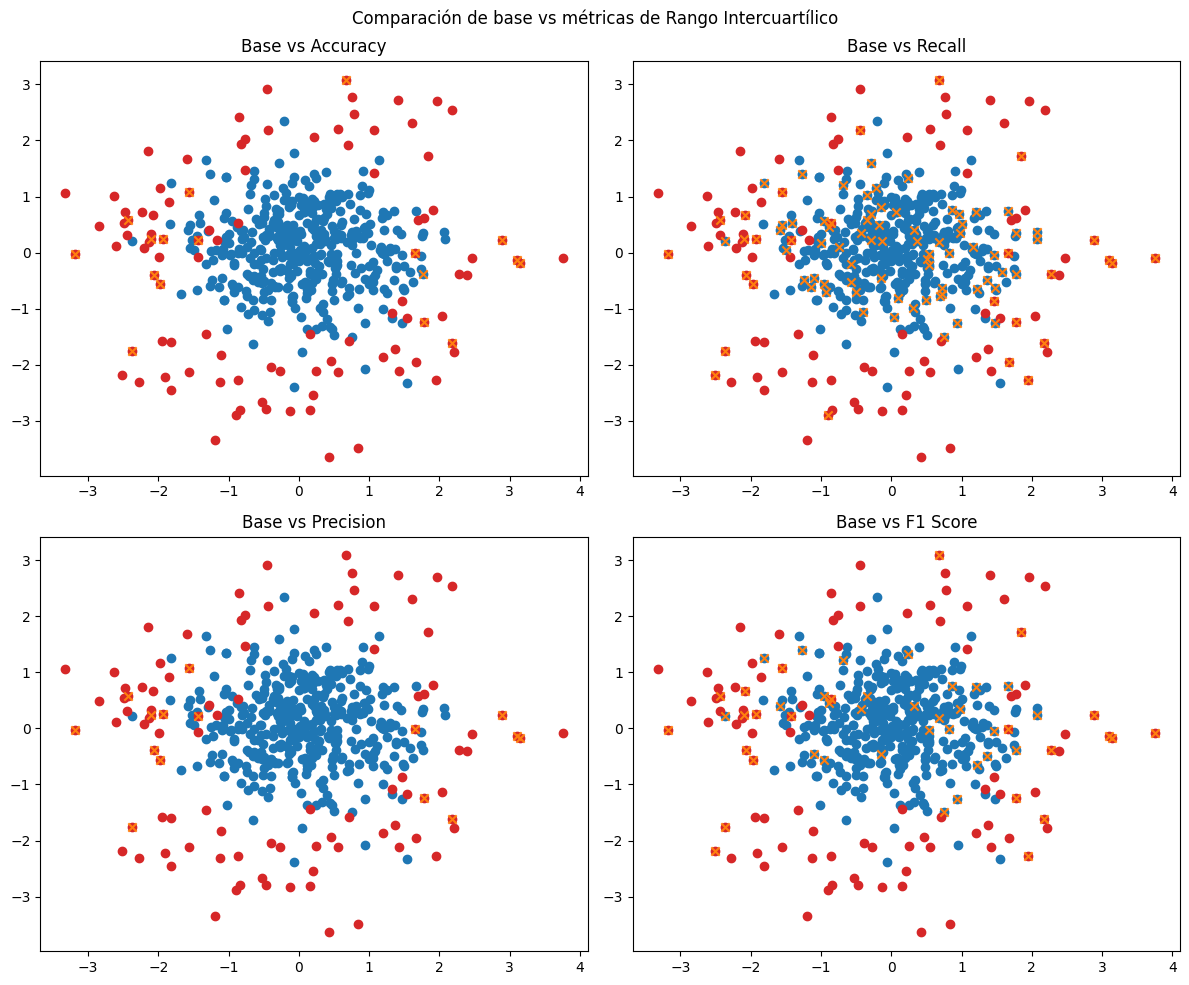

In [16]:
graficos(model, pca, y, outliers_results)

##Eliminar los outliers

In [17]:
df_eliminados = df[~result].copy()
df_eliminados = df_eliminados.drop_duplicates()

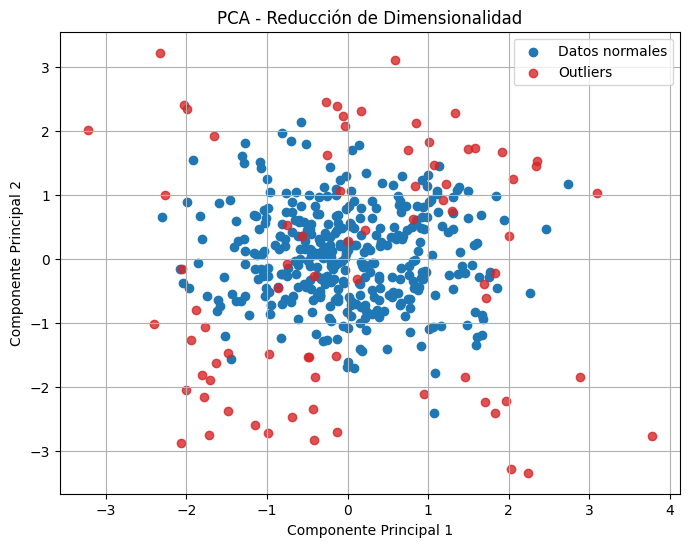

In [18]:
df_iso_eliminados, y, outliers_results = algoritmo(df_eliminados)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_eliminados.drop(columns=['is_outlier']), df_eliminados['is_outlier'])

plt.show()

In [19]:
df_iso_eliminados

,Metric,Best Score,Best umbral,Number of Outliers
0,accuracy,0.828508,0.924242,0
1,recall,0.090909,0.500000,63
2,precision,0.181818,0.803030,11
3,f1,0.100000,0.500000,63


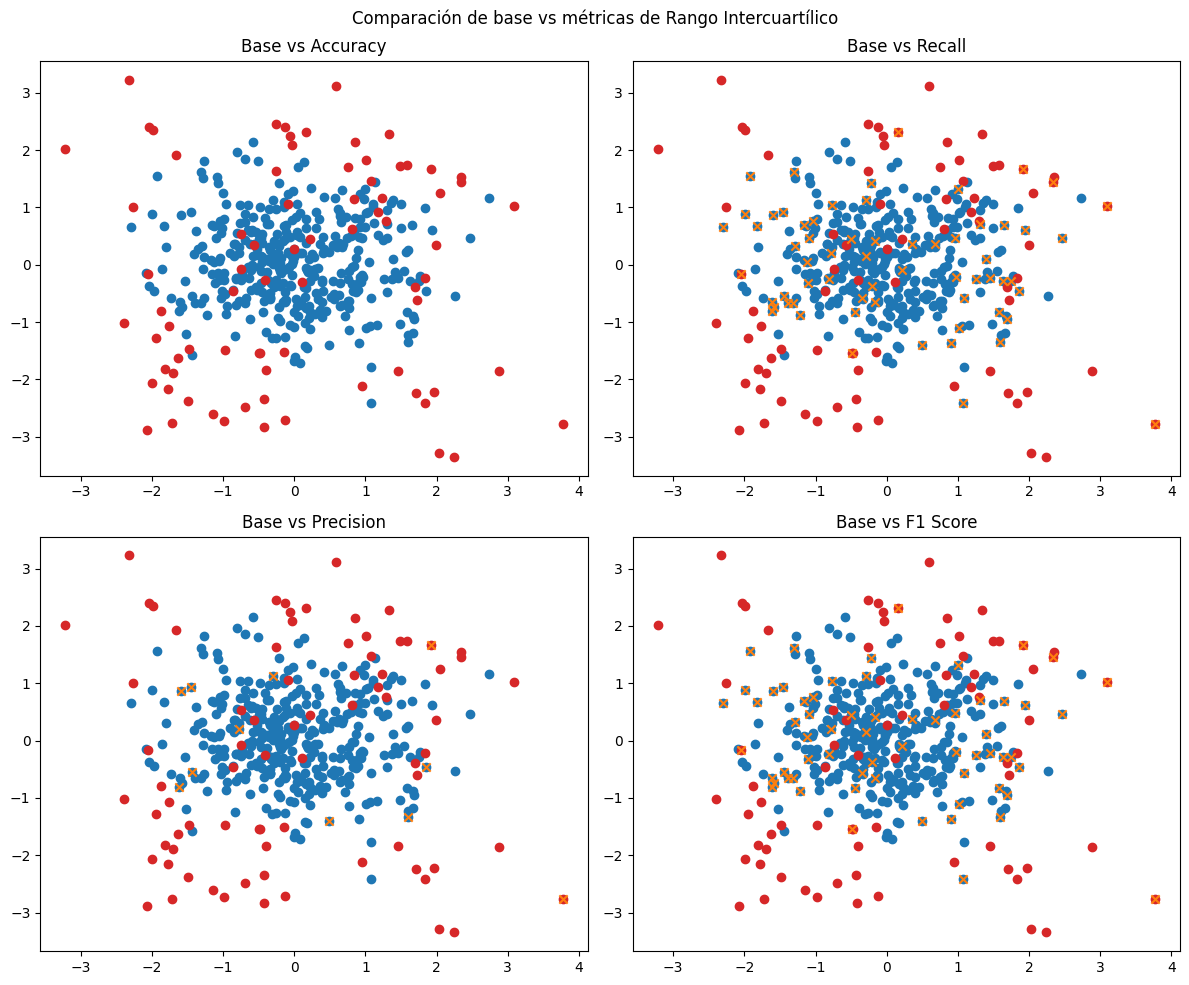

In [20]:
graficos(model, pca, y, outliers_results)

--- Rango Intercuartílico_accuracy ---
              precision    recall  f1-score   support

       Falso       0.83      1.00      0.91       372
   Verdadero       0.00      0.00      0.00        77

    accuracy                           0.83       449
   macro avg       0.41      0.50      0.45       449
weighted avg       0.69      0.83      0.75       449



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Rango Intercuartílico_recall ---
              precision    recall  f1-score   support

       Falso       0.82      0.85      0.83       372
   Verdadero       0.11      0.09      0.10        77

    accuracy                           0.72       449
   macro avg       0.46      0.47      0.47       449
weighted avg       0.70      0.72      0.71       449

--- Rango Intercuartílico_precision ---
              precision    recall  f1-score   support

       Falso       0.83      0.98      0.90       372
   Verdadero       0.18      0.03      0.05        77

    accuracy                           0.81       449
   macro avg       0.51      0.50      0.47       449
weighted avg       0.72      0.81      0.75       449

--- Rango Intercuartílico_f1 ---
              precision    recall  f1-score   support

       Falso       0.82      0.85      0.83       372
   Verdadero       0.11      0.09      0.10        77

    accuracy                           0.72       449
   macro avg      

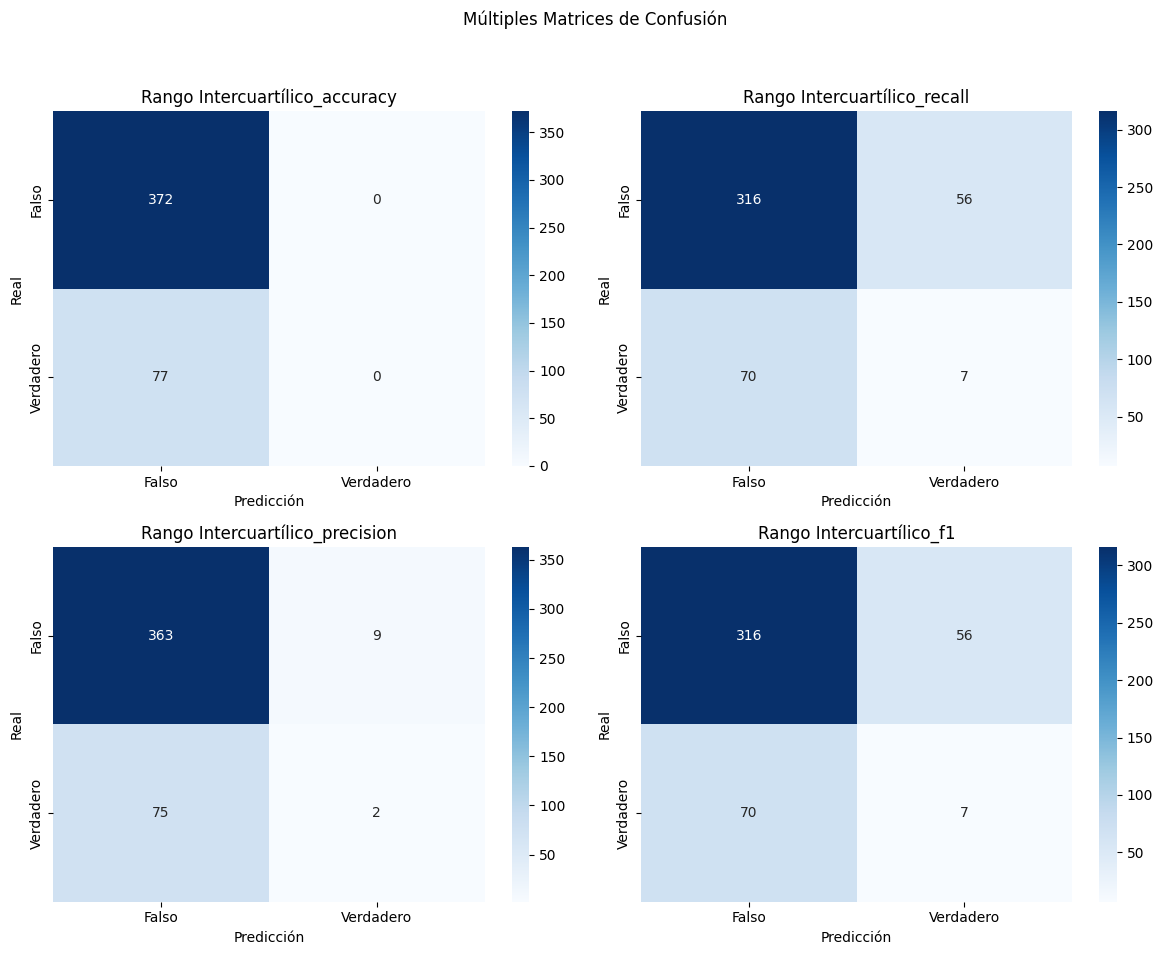

In [21]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)

##Cambiar por la media

In [22]:
# Calcular la mediana de cada columna (solo inliers)
X_mean_aux = df.drop(columns=['is_outlier'])
median_values = np.median(X_mean_aux[~result], axis=0)  # ~outlier_mask = inliers

X_imputed = df.drop(columns=['is_outlier']).copy()
# Reemplazar outliers con la mediana
X_imputed[result] = median_values
df_imputed = pd.DataFrame(X_imputed, columns=X_mean_aux.columns)
df_imputed['is_outlier'] = df['is_outlier'].values  # Asegurar alineación por índice
df_imputed = df_imputed.drop_duplicates()

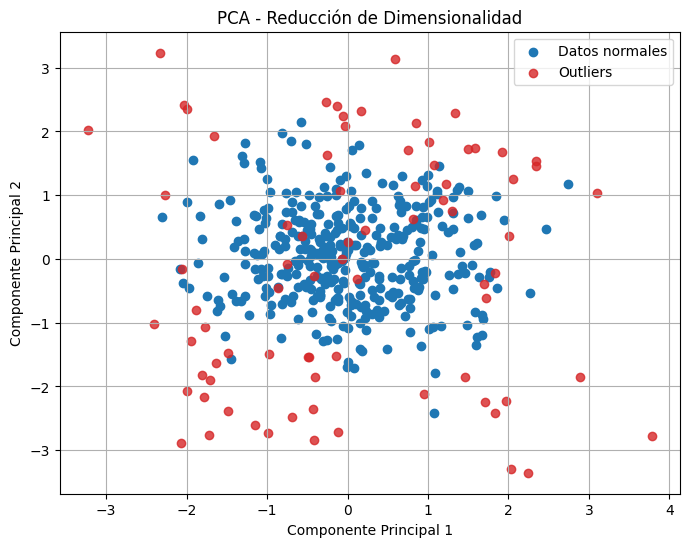

In [23]:
df_iso_imputed, y, outliers_results = algoritmo(df_imputed)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_imputed.drop(columns=['is_outlier']), df_imputed['is_outlier'])

plt.show()

In [24]:
df_iso_imputed

,Metric,Best Score,Best umbral,Number of Outliers
0,accuracy,0.827051,0.924242,0
1,recall,0.089744,0.500000,64
2,precision,0.181818,0.803030,11
3,f1,0.104478,0.530303,56


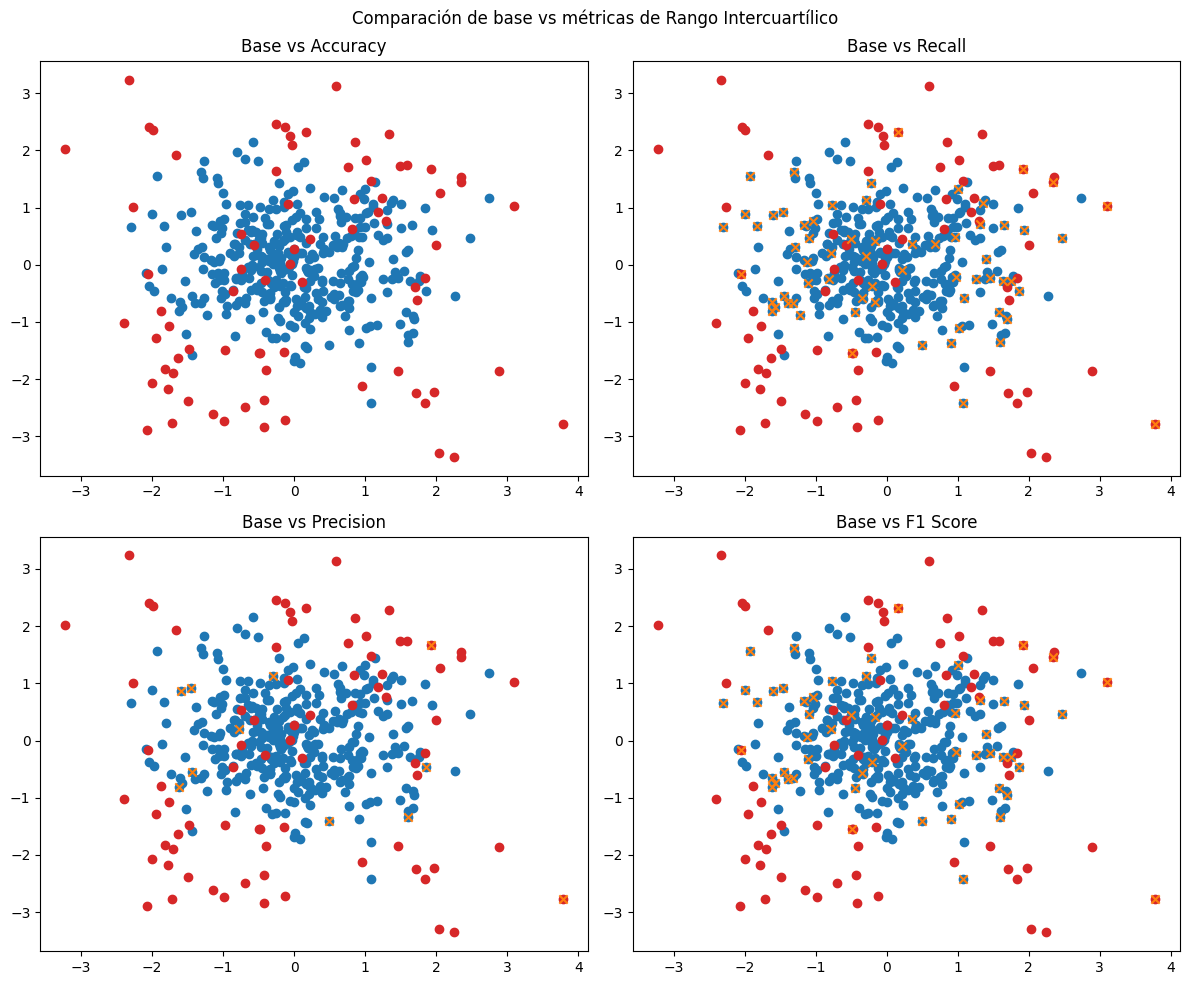

In [25]:
graficos(model, pca, y, outliers_results)

--- Rango Intercuartílico_accuracy ---
              precision    recall  f1-score   support

       Falso       0.83      1.00      0.91       373
   Verdadero       0.00      0.00      0.00        78

    accuracy                           0.83       451
   macro avg       0.41      0.50      0.45       451
weighted avg       0.68      0.83      0.75       451

--- Rango Intercuartílico_recall ---
              precision    recall  f1-score   support

       Falso       0.82      0.85      0.83       373
   Verdadero       0.11      0.09      0.10        78

    accuracy                           0.72       451
   macro avg       0.46      0.47      0.47       451
weighted avg       0.69      0.72      0.70       451



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Rango Intercuartílico_precision ---
              precision    recall  f1-score   support

       Falso       0.83      0.98      0.90       373
   Verdadero       0.18      0.03      0.04        78

    accuracy                           0.81       451
   macro avg       0.50      0.50      0.47       451
weighted avg       0.72      0.81      0.75       451

--- Rango Intercuartílico_f1 ---
              precision    recall  f1-score   support

       Falso       0.82      0.87      0.84       373
   Verdadero       0.12      0.09      0.10        78

    accuracy                           0.73       451
   macro avg       0.47      0.48      0.47       451
weighted avg       0.70      0.73      0.72       451



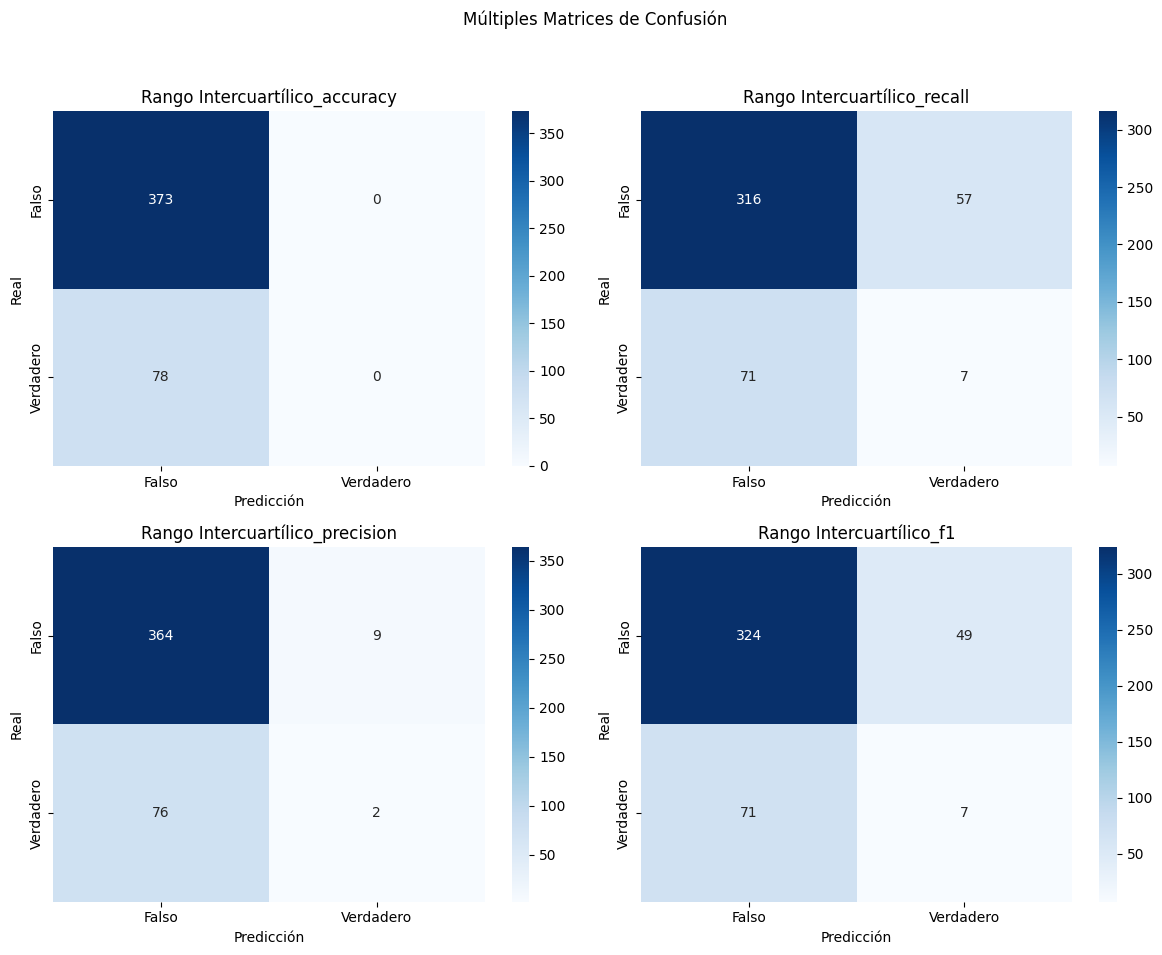

In [26]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)

##Winsorización

In [27]:
# Porcentaje a recortar por ambos extremos (por ejemplo, 1%)
lower_pct = 0.05
upper_pct = 0.95

X_win_aux = df.drop(columns=['is_outlier'])
# Crear copia para winsorizar
X_winsorized = X_win_aux.copy()

# Aplicar winsorización por columnas
for col in X_win_aux.columns:
    lower_bound = X_win_aux[col].quantile(lower_pct)
    upper_bound = X_win_aux[col].quantile(upper_pct)
    X_winsorized[col] = X_win_aux[col].clip(lower=lower_bound, upper=upper_bound)

# Crear DataFrame final con la columna 'is_outlier' original
df_winsorized = pd.DataFrame(X_winsorized, columns=X_win_aux.columns)
df_winsorized['is_outlier'] = df['is_outlier'].values  # Conservar etiquetas de outliers si ya las tenías
df_winsorized = df_winsorized.drop_duplicates()

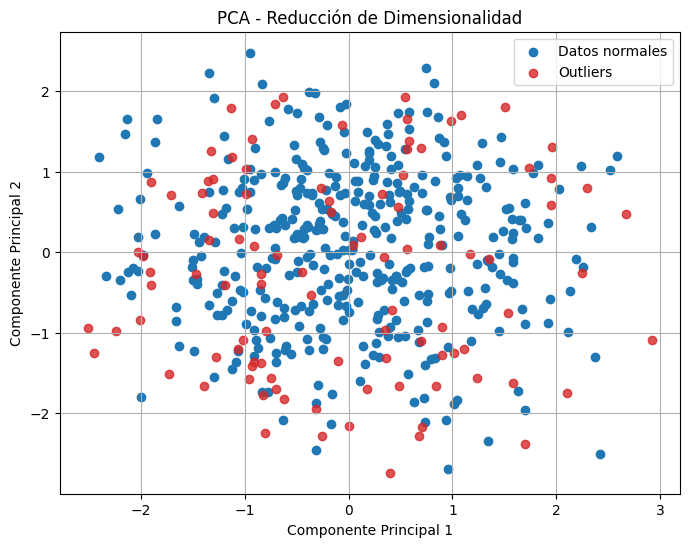

In [28]:
df_iso_imputed, y, outliers_results = algoritmo(df_winsorized)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_winsorized.drop(columns=['is_outlier']), df_winsorized['is_outlier'])

plt.show()

In [29]:
df_iso_imputed

,Metric,Best Score,Best umbral,Number of Outliers
0,accuracy,0.800000,0.803030,0
1,recall,0.270000,0.500000,94
2,precision,0.444444,0.772727,27
3,f1,0.300654,0.742424,53


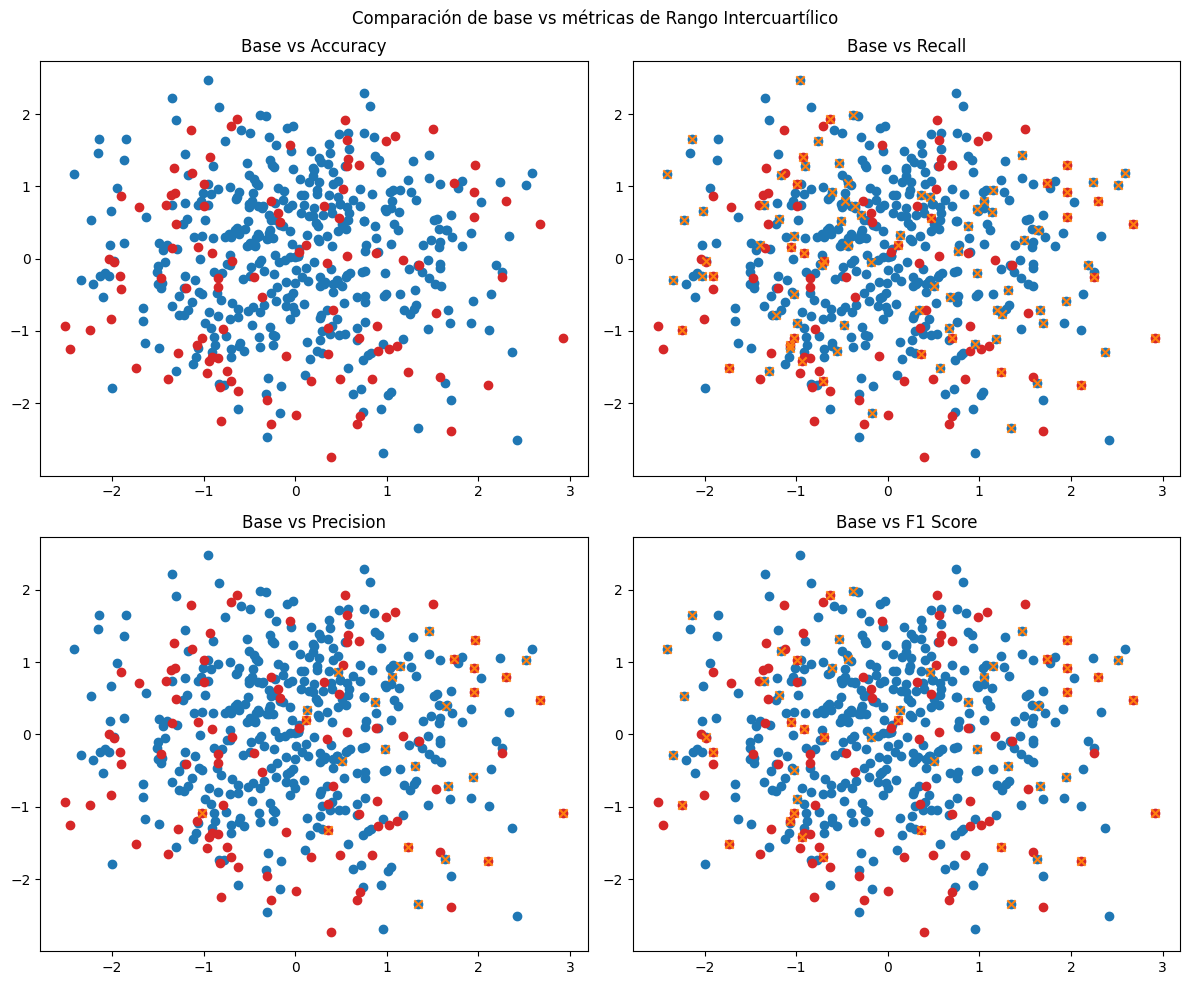

In [30]:
graficos(model, pca, y, outliers_results)

--- Rango Intercuartílico_accuracy ---
              precision    recall  f1-score   support

       Falso       0.80      1.00      0.89       400
   Verdadero       0.00      0.00      0.00       100

    accuracy                           0.80       500
   macro avg       0.40      0.50      0.44       500
weighted avg       0.64      0.80      0.71       500

--- Rango Intercuartílico_recall ---
              precision    recall  f1-score   support

       Falso       0.82      0.83      0.83       400
   Verdadero       0.29      0.27      0.28       100

    accuracy                           0.72       500
   macro avg       0.55      0.55      0.55       500
weighted avg       0.71      0.72      0.72       500



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Rango Intercuartílico_precision ---
              precision    recall  f1-score   support

       Falso       0.81      0.96      0.88       400
   Verdadero       0.44      0.12      0.19       100

    accuracy                           0.79       500
   macro avg       0.63      0.54      0.54       500
weighted avg       0.74      0.79      0.74       500

--- Rango Intercuartílico_f1 ---
              precision    recall  f1-score   support

       Falso       0.83      0.93      0.87       400
   Verdadero       0.43      0.23      0.30       100

    accuracy                           0.79       500
   macro avg       0.63      0.58      0.59       500
weighted avg       0.75      0.79      0.76       500



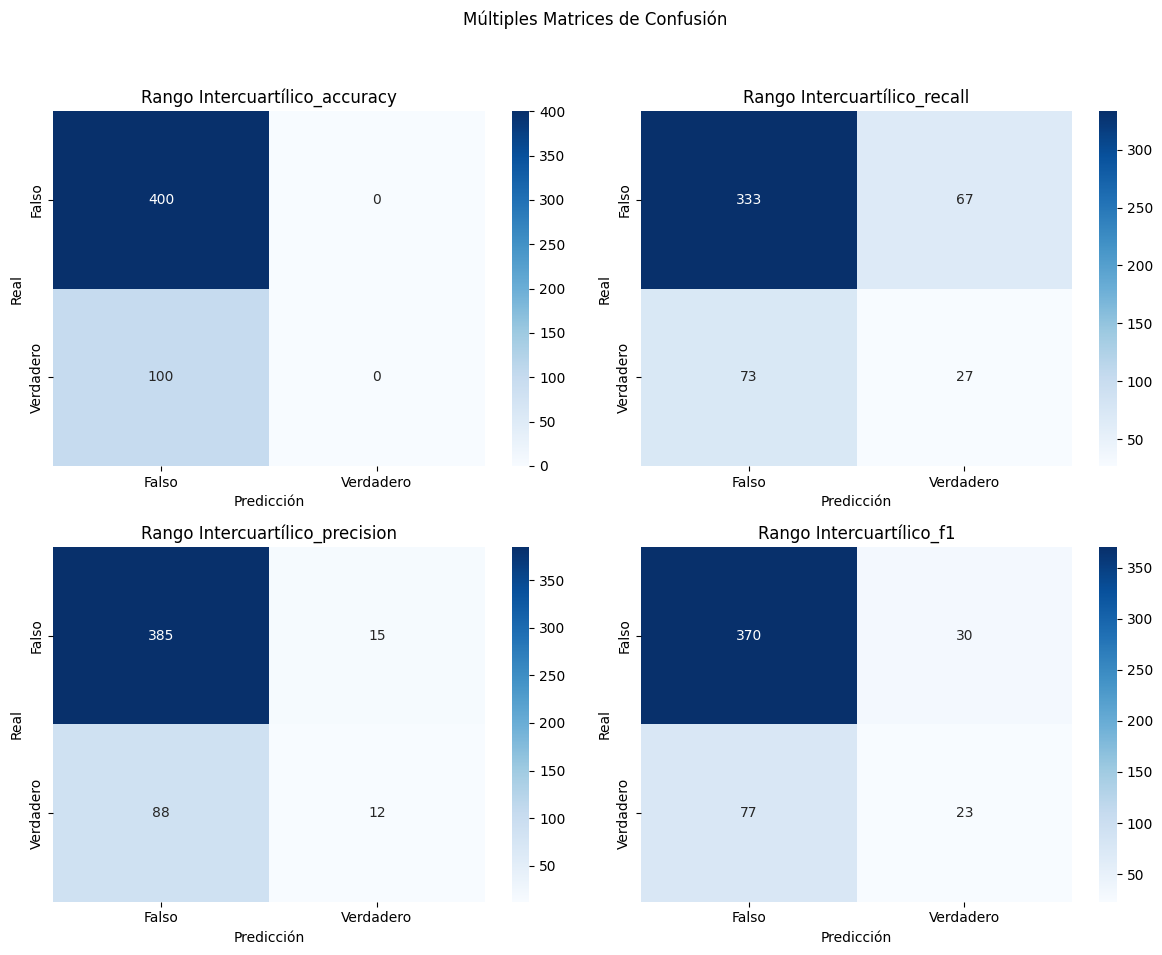

In [31]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)